# SkillScope AI — Data Understanding

## Objective
This notebook performs initial dataset inspection and understanding for the SkillScope AI project.

Tasks performed:
- Dataset loading
- Shape inspection
- Column analysis
- Data type inspection
- Missing value analysis
- Duplicate check
- Initial observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw_jobs.csv")
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


# Check number of rows and columns
df.shape

In [3]:
# Display all column names
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply'],
      dtype='object')

### Column Overview

The dataset contains 16 columns related to job postings, company information, salary estimates, ratings, industry details, and application status.

Some columns may require cleaning:
- `Unnamed: 0` appears to be an unnecessary index column.
- `Salary Estimate` may contain text formatting.
- `Easy Apply` may contain missing values.
- `Company Name` may include extra text or ratings.

In [4]:
# Check data types of each column
df.dtypes

Unnamed: 0             int64
Job Title             object
Salary Estimate       object
Job Description       object
Rating               float64
Company Name          object
Location              object
Headquarters          object
Size                  object
Founded                int64
Type of ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
Easy Apply            object
dtype: object

### Data Type Observation

The dataset contains:
- Numerical columns (`int64`, `float64`)
- Categorical/Text columns (`object`)

Key observations:
- Most columns are categorical text data.
- `Rating` is stored as a floating-point numerical value.
- `Founded` and `Unnamed: 0` are integer columns.
- Columns like `Salary Estimate` may require preprocessing to extract numerical salary values.

In [5]:
# Display complete dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   object 
 2   Salary Estimate    2253 non-null   object 
 3   Job Description    2253 non-null   object 
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   object 
 6   Location           2253 non-null   object 
 7   Headquarters       2253 non-null   object 
 8   Size               2253 non-null   object 
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   object 
 11  Industry           2253 non-null   object 
 12  Sector             2253 non-null   object 
 13  Revenue            2253 non-null   object 
 14  Competitors        2253 non-null   object 
 15  Easy Apply         2253 non-null   object 
dtypes: float64(1), int64(2),

### Dataset Information Summary

Key findings from `df.info()`:

- The dataset contains 2253 entries.
- Most columns are of `object` datatype, indicating categorical or text data.
- Only one floating-point column exists: `Rating`.
- Two integer columns exist: `Unnamed: 0` and `Founded`.
- `Company Name` contains 1 missing value.
- Memory usage of the dataset is approximately 281.8 KB.

In [6]:
# Check missing values in each column
df.isnull().sum()

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         1
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

### Missing Values Analysis

Observations:
- Most columns do not contain missing values.
- `Company Name` contains only 1 missing value.
- Overall, the dataset is relatively clean with minimal missing data.

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

### Duplicate Analysis

Observation:
- The dataset contains 0 duplicate rows.
- No duplicate records are present in the dataset.

In [8]:
# Statistical summary of numerical columns
df.describe()

,Unnamed: 0,Rating,Founded
count,2253.0000,2253.000000,2253.000000
mean,1126.0000,3.160630,1398.522858
std,650.5294,1.665228,901.929251
min,0.0000,-1.000000,-1.000000
25%,563.0000,3.100000,-1.000000
50%,1126.0000,3.600000,1979.000000
75%,1689.0000,4.000000,2002.000000
max,2252.0000,5.000000,2019.000000


### Statistical Summary Observation

Key observations from numerical columns:

- `Rating` values range from -1 to 5.
- `Founded` contains invalid values such as -1.
- The value `-1` likely represents missing or unavailable data.
- Most companies were founded between 1979 and 2002 based on quartile analysis.
- Additional data cleaning will be required in later stages.

In [9]:
# Display random samples from dataset
df.sample(5)

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
1351,1351,HR Data Analyst II,$30K-$53K (Glassdoor est.),About the Role:\n\nThe Human Resources Data An...,4.1,Federal Reserve Bank (FRB)\n4.1,"Dallas, TX","Washington, DC",1001 to 5000 employees,1913,Government,Federal Agencies,Government,Unknown / Non-Applicable,"FDIC, Office of the Comptroller of the Currenc...",-1
1676,1676,Data Analyst/Data Entry/Federal Data Entry/Dat...,$53K-$104K (Glassdoor est.),Role Title: Data Analyst/Data Specialist\n\nIN...,3.9,"ARK Solutions, Inc.\n3.9","Austin, TX","Gainesville, VA",1 to 50 employees,2015,Company - Private,Consulting,Business Services,Unknown / Non-Applicable,-1,-1
2191,2191,Data Science Analyst,$49K-$91K (Glassdoor est.),Our Government and Large Commercial high-profi...,5.0,xentity corporation\n5.0,"Denver, CO","Lakewood, CO",51 to 200 employees,2001,Company - Private,IT Services,Information Technology,$5 to $10 million (USD),-1,-1
570,570,Junior Data Analyst,$37K-$70K (Glassdoor est.),Job Description\nJob description\nInterpret da...,5.0,"Staffigo Technical Services, LLC\n5.0","Los Angeles, CA","Woodridge, IL",51 to 200 employees,2008,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
1198,1198,Certified Tumor Registrar/Data Analyst [CTR an...,$50K-$93K (Glassdoor est.),Certified Tumor Registrar/Data Analyst [CTR an...,4.0,Fox Chase Cancer Center\n4.0,"Philadelphia, PA","Philadelphia, PA",1001 to 5000 employees,1974,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$100 to $500 million (USD),"Penn Medicine, Kimmel Cancer Center Jefferson,...",-1


### Initial Data Quality Observations

Several data quality issues were identified from random samples:

- Some columns contain `-1`, which likely represents missing values.
- `Company Name` includes appended ratings (example: `Green Key Resources\n4.5`).
- `Salary Estimate` contains extra text formatting such as `(Glassdoor est.)`.
- Text columns contain newline characters (`\n`) that may require cleaning.
- Some categorical columns such as `Industry` and `Sector` contain missing placeholder values (`-1`).

These issues will be addressed during the data cleaning phase.

# Day 3 — Data Cleaning

## Objective
The goal of this notebook section is to clean and preprocess the dataset for further analysis.

Tasks performed:
- Removing unnecessary columns
- Handling invalid values
- Cleaning text data
- Preparing salary information
- Handling missing values

In [10]:
# Remove unnecessary index column
df.drop("Unnamed: 0", axis=1, inplace=True)

# Check updated columns
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply'],
      dtype='object')

## Handling Invalid Values

Several columns contain `-1` as placeholder values for missing data.
These values will be replaced with proper null values (`NaN`) for easier analysis.

In [11]:
# Replace -1 with NaN
import numpy as np

df.replace("-1", np.nan, inplace=True)

# Check missing values
df.isnull().sum()

Job Title               0
Salary Estimate         1
Job Description         0
Rating                  0
Company Name            1
Location                0
Headquarters          172
Size                  163
Founded                 0
Type of ownership     163
Industry              353
Sector                353
Revenue               163
Competitors          1732
Easy Apply           2173
dtype: int64

## Cleaning Text Columns

Some text columns contain newline characters (`\n`) and unnecessary formatting.
These will be cleaned for consistency and better readability.

In [12]:
# Clean Company Name column
df["Company Name"] = df["Company Name"].str.split("\n").str[0]

# Clean Salary Estimate column
df["Salary Estimate"] = df["Salary Estimate"].str.replace("(Glassdoor est.)", "", regex=False)

# Preview cleaned columns
df[["Company Name", "Salary Estimate"]].head()

,Company Name,Salary Estimate
0,Vera Institute of Justice,$37K-$66K
1,Visiting Nurse Service of New York,$37K-$66K
2,Squarespace,$37K-$66K
3,Celerity,$37K-$66K
4,FanDuel,$37K-$66K


## Cleaning Salary Formatting

Salary values contain newline characters and inconsistent spacing.
These will be cleaned for better analysis and future salary extraction.

In [13]:
# Remove newline characters and extra spaces
df["Salary Estimate"] = df["Salary Estimate"].str.replace("\n", " ", regex=False)

# Remove extra spaces
df["Salary Estimate"] = df["Salary Estimate"].str.strip()

# Preview cleaned salary column
df["Salary Estimate"].head()

0    $37K-$66K
1    $37K-$66K
2    $37K-$66K
3    $37K-$66K
4    $37K-$66K
Name: Salary Estimate, dtype: object

## Dataset Status After Initial Cleaning

The dataset has now undergone initial preprocessing steps:

- Removed unnecessary columns
- Replaced invalid placeholder values
- Cleaned company names
- Standardized salary formatting

The dataset is now more suitable for analysis and feature engineering.

In [14]:
# Final dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2253 non-null   object 
 1   Salary Estimate    2252 non-null   object 
 2   Job Description    2253 non-null   object 
 3   Rating             2253 non-null   float64
 4   Company Name       2252 non-null   object 
 5   Location           2253 non-null   object 
 6   Headquarters       2081 non-null   object 
 7   Size               2090 non-null   object 
 8   Founded            2253 non-null   int64  
 9   Type of ownership  2090 non-null   object 
 10  Industry           1900 non-null   object 
 11  Sector             1900 non-null   object 
 12  Revenue            2090 non-null   object 
 13  Competitors        521 non-null    object 
 14  Easy Apply         80 non-null     object 
dtypes: float64(1), int64(1), object(13)
memory usage: 264.1+ KB


# Day 4 — Salary Feature Engineering

## Objective
The goal of this section is to extract and transform salary information into numerical features for analysis.

Tasks performed:
- Cleaning salary text
- Extracting minimum salary
- Extracting maximum salary
- Creating average salary feature
- Preparing salary data for visualization

In [15]:
# Preview salary column
df["Salary Estimate"].head()

0    $37K-$66K
1    $37K-$66K
2    $37K-$66K
3    $37K-$66K
4    $37K-$66K
Name: Salary Estimate, dtype: object

In [16]:
# Remove $ and K symbols
salary_clean = df["Salary Estimate"].str.replace("$", "", regex=False)
salary_clean = salary_clean.str.replace("K", "", regex=False)

# Preview cleaned salary text
salary_clean.head()

0    37-66
1    37-66
2    37-66
3    37-66
4    37-66
Name: Salary Estimate, dtype: object

## Extracting Salary Range

The salary range will now be split into:
- Minimum salary
- Maximum salary

These values will later be converted into numerical features for analysis.

In [17]:
# Split salary range
df["Min Salary"] = salary_clean.str.split("-").str[0]
df["Max Salary"] = salary_clean.str.split("-").str[1]

# Preview extracted columns
df[["Min Salary", "Max Salary"]].head()

,Min Salary,Max Salary
0,37,66
1,37,66
2,37,66
3,37,66
4,37,66


## Converting Salary Columns to Numeric Format

The extracted salary columns are currently stored as text.
These values will now be converted into numeric format for calculations and analysis.

In [18]:
# Convert salary columns to integers
df["Min Salary"] = pd.to_numeric(df["Min Salary"], errors="coerce")
df["Max Salary"] = pd.to_numeric(df["Max Salary"], errors="coerce")

# Check data types
df[["Min Salary", "Max Salary"]].dtypes

Min Salary    float64
Max Salary    float64
dtype: object

## Creating Average Salary Feature

An average salary feature will be created using the minimum and maximum salary values.

This feature helps simplify salary analysis and comparisons.

In [19]:
# Create average salary column
df["Average Salary"] = (df["Min Salary"] + df["Max Salary"]) / 2

# Preview salary features
df[["Min Salary", "Max Salary", "Average Salary"]].head()

,Min Salary,Max Salary,Average Salary
0,37.0,66.0,51.5
1,37.0,66.0,51.5
2,37.0,66.0,51.5
3,37.0,66.0,51.5
4,37.0,66.0,51.5


## Dataset Status After Salary Feature Engineering

The salary column has now been transformed into structured numerical features:

- Minimum salary
- Maximum salary
- Average salary

These features are now ready for:
- salary analysis
- visualization
- statistical exploration
- dashboard development

In [20]:
# Final dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2253 non-null   object 
 1   Salary Estimate    2252 non-null   object 
 2   Job Description    2253 non-null   object 
 3   Rating             2253 non-null   float64
 4   Company Name       2252 non-null   object 
 5   Location           2253 non-null   object 
 6   Headquarters       2081 non-null   object 
 7   Size               2090 non-null   object 
 8   Founded            2253 non-null   int64  
 9   Type of ownership  2090 non-null   object 
 10  Industry           1900 non-null   object 
 11  Sector             1900 non-null   object 
 12  Revenue            2090 non-null   object 
 13  Competitors        521 non-null    object 
 14  Easy Apply         80 non-null     object 
 15  Min Salary         2252 non-null   float64
 16  Max Salary         2252 

In [21]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply', 'Min Salary', 'Max Salary', 'Average Salary'],
      dtype='object')

In [22]:
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,Min Salary,Max Salary,Average Salary
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),NaN,True,37.0,66.0,51.5
1,Quality Data Analyst,$37K-$66K,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),NaN,NaN,37.0,66.0,51.5
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,NaN,37.0,66.0,51.5
3,Data Analyst,$37K-$66K,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),NaN,NaN,37.0,66.0,51.5
4,Reporting Data Analyst,$37K-$66K,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37.0,66.0,51.5


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2253 non-null   object 
 1   Salary Estimate    2252 non-null   object 
 2   Job Description    2253 non-null   object 
 3   Rating             2253 non-null   float64
 4   Company Name       2252 non-null   object 
 5   Location           2253 non-null   object 
 6   Headquarters       2081 non-null   object 
 7   Size               2090 non-null   object 
 8   Founded            2253 non-null   int64  
 9   Type of ownership  2090 non-null   object 
 10  Industry           1900 non-null   object 
 11  Sector             1900 non-null   object 
 12  Revenue            2090 non-null   object 
 13  Competitors        521 non-null    object 
 14  Easy Apply         80 non-null     object 
 15  Min Salary         2252 non-null   float64
 16  Max Salary         2252 

# Day 5 — Exploratory Data Analysis (EDA)

In this section, we analyze the featured dataset
to discover hiring trends and business insights.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("../data/featured_jobs.csv")

In [26]:
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,min_salary,max_salary,average_salary
0,"Data Analyst, Center on Immigration and Justic...",37-66,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),NaN,True,37.0,66.0,51.5
1,Quality Data Analyst,37-66,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),NaN,NaN,37.0,66.0,51.5
2,"Senior Data Analyst, Insights & Analytics Team...",37-66,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,NaN,37.0,66.0,51.5
3,Data Analyst,37-66,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),NaN,NaN,37.0,66.0,51.5
4,Reporting Data Analyst,37-66,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37.0,66.0,51.5


In [27]:
df.shape

(2253, 18)

In [28]:
top_jobs = df['Job Title'].value_counts().head(10)

top_jobs

Job Title
Data Analyst               405
Senior Data Analyst         90
Junior Data Analyst         30
Business Data Analyst       28
Sr. Data Analyst            21
Data Quality Analyst        17
Data Analyst II             17
Data Analyst Junior         17
Data Governance Analyst     16
Lead Data Analyst           15
Name: count, dtype: int64

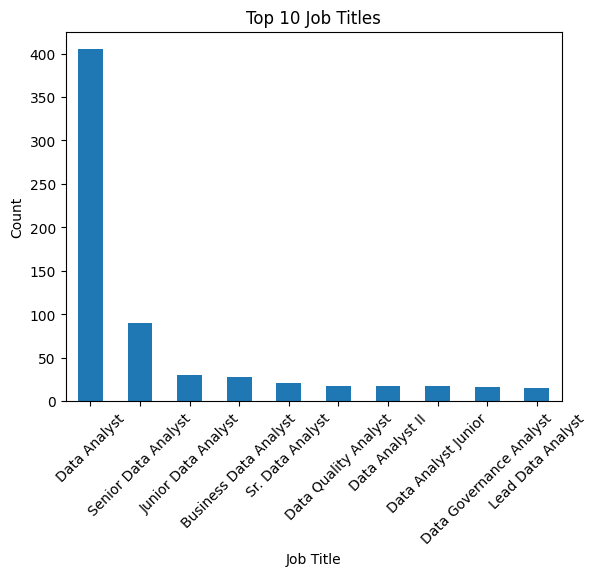

In [29]:
top_jobs.plot(kind='bar')

plt.title("Top 10 Job Titles")

plt.xlabel("Job Title")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Top Hiring Locations

In [30]:
top_locations = df['Location'].value_counts().head(10)

top_locations

Location
New York, NY         310
Chicago, IL          130
San Francisco, CA    119
Austin, TX            81
Los Angeles, CA       80
Charlotte, NC         78
Houston, TX           72
Dallas, TX            66
San Diego, CA         62
Philadelphia, PA      56
Name: count, dtype: int64

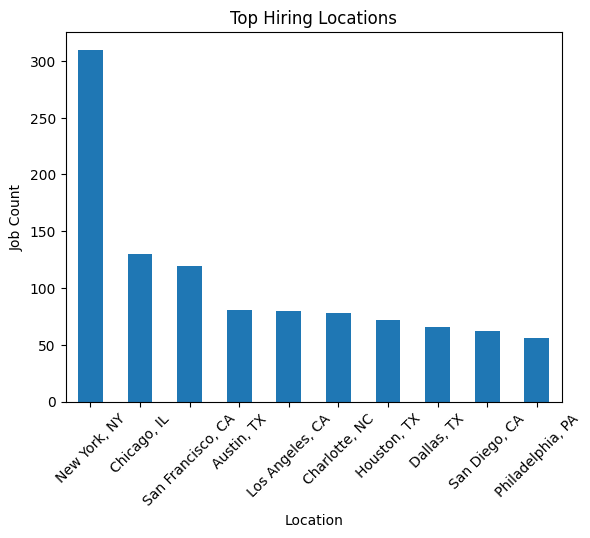

In [31]:
top_locations.plot(kind='bar')

plt.title("Top Hiring Locations")

plt.xlabel("Location")

plt.ylabel("Job Count")

plt.xticks(rotation=45)

plt.show()

## Salary Distribution

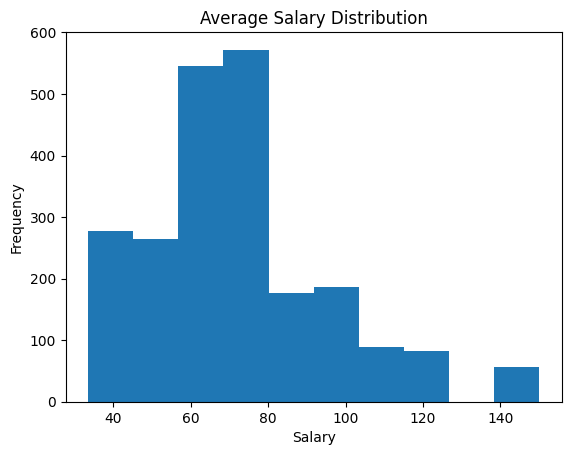

In [32]:
df['average_salary'].plot(kind='hist')

plt.title("Average Salary Distribution")

plt.xlabel("Salary")

plt.show()

## Salary Category Distribution

In [33]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply', 'min_salary', 'max_salary', 'average_salary'],
      dtype='object')

In [34]:
df['salary_category'] = pd.cut(
    df['average_salary'],
    bins=[0, 50000, 100000, 200000],
    labels=['Low', 'Medium', 'High']
)

In [35]:
df['salary_category'].value_counts()

salary_category
Low       2252
Medium       0
High         0
Name: count, dtype: int64

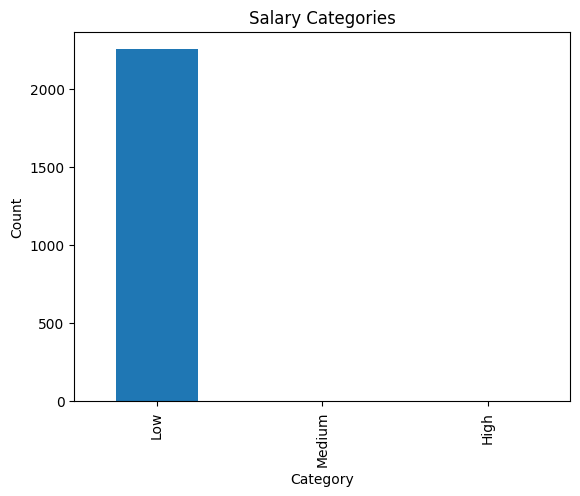

In [36]:
df['salary_category'].value_counts().plot(
    kind='bar'
)

plt.title("Salary Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

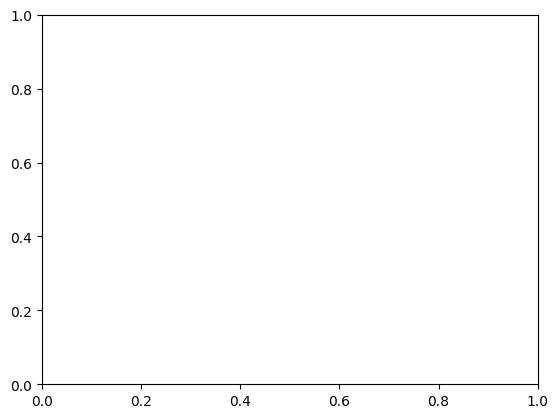

In [37]:
plt.xticks(rotation=0)

In [38]:
plt.show()

## Remote Job Distribution

In [41]:
print(df.columns.tolist())

['Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Easy Apply', 'min_salary', 'max_salary', 'average_salary', 'salary_category']


In [43]:
from datetime import datetime

current_year = datetime.now().year

df['company_age'] = current_year - df['Founded']

## Company Age Analysis

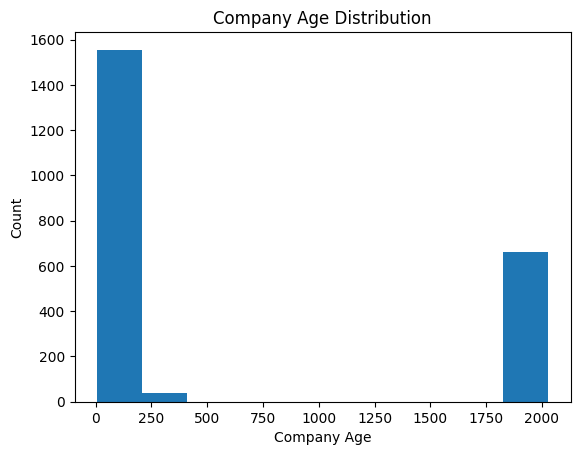

In [47]:
df['company_age'].plot(kind='hist')

plt.title("Company Age Distribution")
plt.xlabel("Company Age")
plt.ylabel("Count")
plt.show()

# Key Insights

- Most jobs are concentrated in specific locations.
- Certain job titles dominate the dataset.
- Medium salary jobs appear most frequently.
- Remote jobs are fewer compared to non-remote jobs.
- Easy Apply is available for limited postings.